In [58]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt


In [59]:
aluminium_usgs_image_mapping ={
    'class_ 1': ['Canada'],
    'class_ 2': ['United States'],
    'class_ 3': ['Mexico'],
    'class_ 4': [],
    'class_ 5': ['Brazil'],
    'class_ 6': ['Argentina', 'Suriname', 'Venezuela'],
    'class_ 7': ['Egypt'],
    'class_ 8': ['Cameroon', 'Ghana', 'Nigeria'],
    'class_ 9': ['Mozambique'],
    'class_ 10': ['South Africa'],
    'class_ 11': [
        'Austria', 'France', 'Germany', 'Greece', 'Iceland',
        'Italy', 'Netherlands', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom'],
    'class_ 12': [
        'Bosnia and Herzegovina', 'Croatia', 'Czechoslovakia3', 'Hungary',
        'Montenegro', 'Poland', 'Romania', 'Serbia and Montenegro4', 'Slovakia',
        'Slovenia', 'Yugoslavia6'],
    'class_ 13': ['Turkey'],
    'class_ 14': ['Ukraine'],
    'class_ 15': ['Kazakhstan', 'Tajikistan'],
    'class_ 16': ['Russia', 'U.S.S.R.5'],
    'class_ 17': ['Azerbaijan', 'Bahrain', 'Iran', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates'],
    'class_ 18': ['India'],
    'class_ 19': ['Korea, Republic of'],
    'class_ 20': ['China'],
    'class_ 21': ['Malaysia'],
    'class_ 22': ['Indonesia'],
    'class_ 23': ['Japan'],
    'class_ 24': ['Australia', 'New Zealand'],
    'class_ 25': [],
    'class_ 26': [],
    'class_ 27': ['World']
    }

region_to_class = {
    'Argentina': 'class_ 6',  # Rest S.Am.
    'Australia': 'class_ 24',  # Oceania
    'Austria': 'class_ 11',  # W.Europe
    'Azerbaijan': 'class_ 17',  # M.East (also arguable: Stan or Reforming)
    'Bahrain': 'class_ 17',  # M.East
    'Bosnia and Herzegovina': 'class_ 12',  # C.Europe
    'Brazil': 'class_ 5',
    'Cameroon': 'class_ 8',  # W.Africa
    'Canada': 'class_ 1',
    'China': 'class_ 20',
    'Croatia': 'class_ 12',  # C.Europe
    'Czechoslovakia3': 'class_ 12',  # C.Europe (historical)
    'Egypt': 'class_ 7',  # N.Africa
    'France': 'class_ 11',
    'Germany': 'class_ 11',
    'Ghana': 'class_ 8',  # W.Africa
    'Greece': 'class_ 11',
    'Hungary': 'class_ 12',
    'Iceland': 'class_ 11',
    'India': 'class_ 18',
    'Indonesia': 'class_ 22',
    'Iran': 'class_ 17',  # M.East
    'Italy': 'class_ 11',
    'Japan': 'class_ 23',
    'Kazakhstan': 'class_ 15',  # Stan
    'Korea, Republic of': 'class_ 19',
    'Malaysia': 'class_ 21',  # SE.Asia
    'Mexico': 'class_ 3',
    'Montenegro': 'class_ 12',
    'Mozambique': 'class_ 9',  # E.Africa
    'Netherlands': 'class_ 11',
    'New Zealand': 'class_ 24',
    'Nigeria': 'class_ 8',  # W.Africa
    'Norway': 'class_ 11',
    'Oman': 'class_ 17',  # M.East
    'Poland': 'class_ 12',
    'Qatar': 'class_ 17',
    'Romania': 'class_ 12',
    'Russia': 'class_ 16',
    'Saudi Arabia': 'class_ 17',
    'Serbia and Montenegro4': 'class_ 12',
    'Slovakia': 'class_ 12',
    'Slovenia': 'class_ 12',
    'South Africa': 'class_ 10',
    'Spain': 'class_ 11',
    'Suriname': 'class_ 6',  # Rest S.Am.
    'Sweden': 'class_ 11',
    'Switzerland': 'class_ 11',
    'Tajikistan': 'class_ 15',  # Stan
    'Turkey': 'class_ 13',
    'Ukraine': 'class_ 14',
    'U.S.S.R.5': 'class_ 16',
    'United Arab Emirates': 'class_ 17',
    'United Kingdom': 'class_ 11',
    'United States': 'class_ 2',
    'Venezuela': 'class_ 6',
    'Yugoslavia6': 'class_ 12',
    'World': 'class_ 27'
}


ISO_TO_CLASS = {
    'CAN': 'class_ 1',
    'USA': 'class_ 2',
    'MEX': 'class_ 3',
    'BLZ': 'class_ 4', 'GTM': 'class_ 4', 'NIC': 'class_ 4', 'PAN': 'class_ 4',
    'CUB': 'class_ 4', 'DOM': 'class_ 4', 'ANT': 'class_ 4', 'HTI': 'class_ 4',
    'JAM': 'class_ 4', 'TTO': 'class_ 4', 'ATG': 'class_ 4', 'KNA': 'class_ 4',
    'LCA': 'class_ 4', 'VCT': 'class_ 4', 'GRD': 'class_ 4', 'BHS': 'class_ 4',
    'BRB': 'class_ 4', 'DMA': 'class_ 4', 'CUW': 'class_ 4', 'CYM': 'class_ 4',
    'ARG': 'class_ 6', 'CHL': 'class_ 6', 'COL': 'class_ 6', 'ECU': 'class_ 6',
    'GUY': 'class_ 6', 'PER': 'class_ 6', 'PRY': 'class_ 6', 'SUR': 'class_ 6',
    'URY': 'class_ 6', 'VEN': 'class_ 6', 'BOL': 'class_ 6', 'GUF': 'class_ 6',
    'DZA': 'class_ 7', 'EGY': 'class_ 7', 'MAR': 'class_ 7', 'TUN': 'class_ 7',
    'LBY': 'class_ 7',
    'CMR': 'class_ 8', 'CIV': 'class_ 8', 'GHA': 'class_ 8', 'GIN': 'class_ 8',
    'GMB': 'class_ 8', 'SEN': 'class_ 8', 'TGO': 'class_ 8', 'BEN': 'class_ 8',
    'MLI': 'class_ 8', 'NGA': 'class_ 8', 'BFA': 'class_ 8', 'NER': 'class_ 8',
    'ETH': 'class_ 9', 'KEN': 'class_ 9', 'UGA': 'class_ 9', 'RWA': 'class_ 9',
    'BDI': 'class_ 9', 'TZA': 'class_ 9', 'DJI': 'class_ 9', 'SOM': 'class_ 9',
    'ERI': 'class_ 9', 'SSD': 'class_ 9',
    'ZAF': 'class_ 10', 'SWZ': 'class_ 10', 'LSO': 'class_ 10',
    'NAM': 'class_ 10', 'BWA': 'class_ 10',
    'AUT': 'class_ 11', 'BEL': 'class_ 11', 'DEU': 'class_ 11',
    'DNK': 'class_ 11', 'ESP': 'class_ 11', 'FIN': 'class_ 11',
    'FRA': 'class_ 11', 'GBR': 'class_ 11', 'GRC': 'class_ 11',
    'IRL': 'class_ 11', 'ISL': 'class_ 11', 'ITA': 'class_ 11',
    'LUX': 'class_ 11', 'NLD': 'class_ 11', 'NOR': 'class_ 11',
    'PRT': 'class_ 11', 'SWE': 'class_ 11', 'CHE': 'class_ 11',
    'ALB': 'class_ 12', 'BGR': 'class_ 12', 'BIH': 'class_ 12',
    'CZE': 'class_ 12', 'HRV': 'class_ 12', 'HUN': 'class_ 12',
    'MDA': 'class_ 12', 'MKD': 'class_ 12', 'MNE': 'class_ 12',
    'POL': 'class_ 12', 'ROU': 'class_ 12', 'SCG': 'class_ 12',
    'SRB': 'class_ 12', 'SVK': 'class_ 12', 'SVN': 'class_ 12',
    'TUR': 'class_ 13',
    'UKR': 'class_ 14', 'BLR': 'class_ 14',
    'KAZ': 'class_ 15', 'KGZ': 'class_ 15', 'TJK': 'class_ 15',
    'TKM': 'class_ 15', 'UZB': 'class_ 15',
    'RUS': 'class_ 16',
    'BHR': 'class_ 17', 'IRN': 'class_ 17', 'IRQ': 'class_ 17',
    'ISR': 'class_ 17', 'JOR': 'class_ 17', 'KWT': 'class_ 17',
    'LBN': 'class_ 17', 'OMN': 'class_ 17', 'PSE': 'class_ 17',
    'QAT': 'class_ 17', 'SAU': 'class_ 17', 'SYR': 'class_ 17',
    'ARE': 'class_ 17', 'YEM': 'class_ 17',
    'IND': 'class_ 18',
    'KOR': 'class_ 19',
    'CHN': 'class_ 20', 'HKG': 'class_ 20', 'MAC': 'class_ 20',
    'MYS': 'class_ 21', 'SGP': 'class_ 21', 'THA': 'class_ 21',
    'VNM': 'class_ 21', 'PHL': 'class_ 21', 'MMR': 'class_ 21',
    'KHM': 'class_ 21', 'LAO': 'class_ 21',
    'IDN': 'class_ 22',
    'JPN': 'class_ 23',
    'AUS': 'class_ 24', 'NZL': 'class_ 24', 'FJI': 'class_ 24',
    'VUT': 'class_ 24', 'TON': 'class_ 24', 'WSM': 'class_ 24',
    'PNG': 'class_ 24', 'SLB': 'class_ 24', 'WLF': 'class_ 24',
    'TUV': 'class_ 24', 'NRU': 'class_ 24', 'KIR': 'class_ 24',
    'COK': 'class_ 24', 'PYF': 'class_ 24', 'NCL': 'class_ 24',
    'LKA': 'class_ 25', 'BGD': 'class_ 25', 'NPL': 'class_ 25',
    'MDV': 'class_ 25', 'BTN': 'class_ 25', 'AFG': 'class_ 25',
    'PAK': 'class_ 25',
    'MOZ': 'class_ 26', 'ZMB': 'class_ 26', 'ZWE': 'class_ 26',
    'AGO': 'class_ 26', 'COD': 'class_ 26', 'CAF': 'class_ 26',
    'GAB': 'class_ 26', 'COG': 'class_ 26', 'STP': 'class_ 26',
    'SLE': 'class_ 26', 'GNQ': 'class_ 26', 'TCD': 'class_ 26',
    'MWI': 'class_ 26',
    # 'class_ 27' is for Global — not mapped to ISO
}

In [ ]:
# read in Aluminium trade data from UN comtrade database (https://comtradeplus.un.org/)
# trade data available from 1988 on
# use Imports and Exports for – HS 7601 (Unwrought aluminium), 7602 (Aluminium waste and scrap) for all regions
# for now exclude  7603–7616 (final products to avoid double counting) - could be worth to check later
# read in in 4 steps, as database does not allow selection of more years at once
# unit: kg

alu_1988_1999 = pd.read_csv('alu_trade_1988_1999_qty.csv', 
                   encoding="iso-8859-1", index_col=False)

alu_2000_2011 = pd.read_csv('alu_trade_2000_2011_qty.csv', 
                     encoding="iso-8859-1", index_col=False)

alu_2012_2023 = pd.read_csv('alu_trade_2012_2023_qty.csv', 
                   encoding="iso-8859-1", index_col=False)

alu_2024 = pd.read_csv('alu_trade_2024_qty.csv',
                   encoding="iso-8859-1", index_col=False)

alu_trade = pd.concat([alu_1988_1999, alu_2000_2011, alu_2012_2023, alu_2024])
alu_trade = alu_trade/1000  # convert to tons

# read in global production data from IAI (International Aluminium Institute) https://international-aluminium.org/ 
# unit: 1000 tons
# data given on monthly basis 
alu_production_aia = pd.read_csv('aia_alu_global_production.csv', 
                                 parse_dates=["Period from", "Period to"], 
                                 delimiter=';', header=0)

alu_production_aia["Year"] = alu_production_aia["Period from"].dt.year
alu_production_aia = alu_production_aia.groupby("Year").sum(numeric_only=True)

# read in global production data from USGS (United States Geological Survey) https://www.usgs.gov/centers/national-minerals-information-center/historical-global-statistics-mineral-and-material
# Aluminum ds896-aluminum.xlsx  1990-2012
# unit: metric tons

alu_production_usgs = pd.read_excel('usgs_alu_global_production.xlsx', index_col=0, header = 0)
alu_production_usgs = alu_production_usgs.T

Text(0.5, 1.0, 'Global Aluminium Production Comparison (USGS vs AIA)')

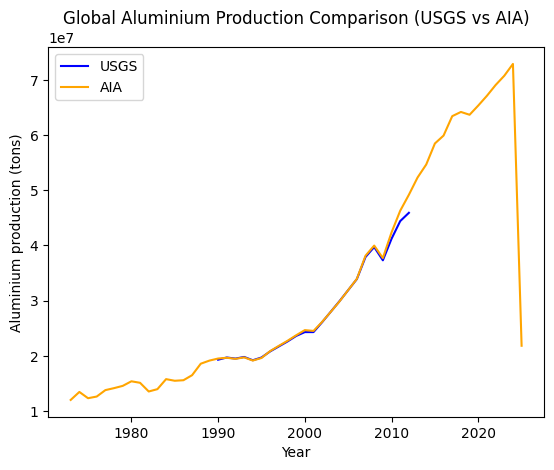

In [61]:
# Plot to compare total USGS producuction data to total AIA productino data

fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(alu_production_usgs.loc[:, 'World'], label = 'USGS', color='blue')
ax.plot(alu_production_aia.sum(axis = 1)*1000, label = 'AIA', color='orange') # Convert AIA data from 1000 tons to tons


ax.legend(loc='upper left')
ax.set_xlabel('Year')
ax.set_ylabel('Aluminium production (tons)')
ax.set_title('Global Aluminium Production Comparison (USGS vs AIA)')



In [62]:
# Continue with USGS data beacuse more regions available and data is 100% similar to AIA data

# map USGS regions to IMAGE regions
alu_production_usgs_image = alu_production_usgs.rename(columns=region_to_class)
# Class 4, 25, and 26 are empty - fill with nan
alu_production_usgs_image.loc[:, 'class_ 4'] = np.nan   # Central America
alu_production_usgs_image.loc[:, 'class_ 25'] = np.nan  # South Asia
alu_production_usgs_image.loc[:, 'class_ 26'] = np.nan  # Sub-Saharan Africa

# Aggregate by IAMGE classes
alu_production_usgs_image = alu_production_usgs_image.T.groupby(level=0).sum().T

# make sure all index is int
alu_production_usgs_image.index = alu_production_usgs_image.index.astype(int)

In [63]:
# Manipulate trade data to also match the IMAGE data strucutre.
# also pivot the trade data to have imports and exports in separate columns
# calculate net trade as imports - exports

# Pivot: sum imports (M) and exports (X) by year and region
trade_pivot = alu_trade.pivot_table(
    index=['refYear', 'reporterISO'],
    columns='flowCode',
    values='qty',
    aggfunc='sum',
    fill_value=0  # Replace NaNs with 0 if there's only import or export
).reset_index()

# Calculate net trade: imports - exports
trade_pivot['netTrade_kg'] = trade_pivot.get('M', 0) - trade_pivot.get('X', 0)

# Map ISO to class
trade_pivot['region'] = trade_pivot['reporterISO'].map(ISO_TO_CLASS)

# Group by class and sum the relevant columns
trade_image = trade_pivot.groupby(['refYear','region'])[['M', 'X', 'netTrade_kg']].sum().reset_index()

# Pivot again to get class as columns, year as index and net trade as values
trade_image_pivot = trade_image.pivot(index='refYear', columns='region', values='netTrade_kg')

In [65]:
alu_production_usgs_image - trade_image_pivot

,class_ 1,class_ 10,class_ 11,class_ 12,class_ 13,class_ 14,class_ 15,class_ 16,class_ 17,class_ 18,...,class_ 25,class_ 26,class_ 27,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9
1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,1.305910e+09,NaN,-5.216415e+08,1.267050e+08,-90951096.0,NaN,NaN,NaN,2.176161e+06,3617007.0,...,-7770219.0,2.994900e+04,NaN,-29752302.0,NaN,NaN,7.144030e+05,NaN,NaN,NaN
1991,1.528249e+09,NaN,-5.682762e+08,6.462200e+07,-57918699.0,NaN,NaN,NaN,2.524800e+08,53167035.0,...,-9469417.0,3.316700e+04,NaN,-51202006.0,1.498695e+06,NaN,-3.421671e+07,-1.851937e+06,NaN,NaN
1992,1.665707e+09,NaN,-4.523415e+08,5.477788e+07,-76070320.0,NaN,NaN,NaN,2.530980e+08,97545271.0,...,-9210112.0,NaN,NaN,-49051730.0,1.433865e+06,NaN,-4.876116e+07,-5.172764e+06,NaN,-2978051.00
1993,1.880579e+09,NaN,-9.142611e+07,-3.465910e+07,-118687202.0,NaN,NaN,NaN,2.768908e+08,-924619.0,...,-11947169.0,3.324900e+04,NaN,-100423309.0,5.734910e+05,NaN,3.783048e+07,-9.906319e+06,NaN,NaN
1994,1.911319e+09,NaN,-1.808540e+09,2.370773e+08,-53427035.0,NaN,NaN,NaN,-1.163585e+07,-31763108.0,...,-1459233.0,8.528300e+04,NaN,-72092452.0,6.019420e+05,NaN,5.018570e+08,-5.269522e+07,NaN,-35419.00
1995,1.767944e+09,NaN,-1.982837e+09,-1.762476e+07,-86374162.0,NaN,2.767290e+07,NaN,6.185194e+07,-73909274.0,...,-15188.0,3.758533e+06,NaN,10923117.0,5.047729e+06,NaN,4.710191e+08,6.582041e+07,6.018518e+07,-1829700.00
1996,1.857149e+09,NaN,-1.810736e+09,7.270986e+07,-88438115.0,100348068.0,1.981133e+07,2.653814e+09,1.230790e+07,-71797306.0,...,-10405538.0,1.992090e+05,NaN,-37148411.0,8.485602e+06,NaN,5.637676e+08,9.228811e+07,1.329176e+08,-158289.00
1997,1.890858e+09,NaN,-2.325882e+09,8.315740e+07,-161895914.0,167848207.0,4.944913e+07,2.907484e+09,-6.687579e+07,-15155502.0,...,-14312774.0,1.761273e+06,NaN,-69820896.0,8.735752e+06,NaN,4.234730e+08,8.559562e+07,1.434393e+08,-3908900.00
